# Lab: Decision Trees

*In this lab, we will build a Decision Tree model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

## Stages 1-5: Business Understanding to Data Understanding
This lab notebook builds directly on the findings from the [Multi-Class Classification Lab](./07_multi_class_classification_lab.ipynb), where we aimed to build a predictive model a model to classify species using flower measurements, reducing need for manual inspection. Therefore Stages 1 through 5 (Business Understanding, Analytic Approach, Data Requirements, Data Collection, and Data Understanding) are considered complete. We will proceed directly with preparing the data for our new Decision Tree model.

---

> ### 📝 1–5. Previous Stages Report (Summary)
> 
> * **Solid Multi-Class Foundations:** In the previous Multi-Class Classification lab, we successfully developed robust baseline models (Softmax Regression, One-vs-Rest, One-vs-One) to classify iris species using flower measurements. All models achieved strong accuracy and well-balanced precision/recall across classes, confirming that the features in the Iris dataset are highly predictive of species.
> * **Key Insights:** Exploratory Data Analysis revealed that petal length and petal width provide almost perfect class separability, with the three species nearly linearly separable in feature space. The dataset is balanced, with no missing values and only minor natural outliers. However, an extremely strong correlation (r=0.96) between petal length and petal width was noted, emphasizing the importance of feature engineering and selection.
> * **Business Objective Met (So Far):** Initial analytic goals were achieved: the models enable rapid, automated species identification, offering a practical alternative to manual inspection for botanical institutes.
> * **New Modeling Direction:** With a clean dataset and high-performing baseline models established, the project now transitions to tree-based methods. The goal is to evaluate Decision Trees both as an interpretable classifier and as a foundation for future ensemble methods. We will proceed directly to data preparation and model development.

---

## Stage 6: Data Preparation

As usual, we start with importing the necessary libraries and configuring them.

In [48]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

Let's load our already processed dataset into a DataFrame:

In [49]:
iris_df = pd.read_parquet("../data/processed/iris_multi-class_processed_v1.parquet")
iris_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,target,class_name,petal_area,sepal_ratio
118,7.7,2.6,6.9,2.3,2,virginica,15.87,2.961538
126,6.2,2.8,4.8,1.8,2,virginica,8.64,2.214286
39,5.1,3.4,1.5,0.2,0,setosa,0.30,1.500000
9,4.9,3.1,1.5,0.1,0,setosa,0.15,1.580645
128,6.4,2.8,5.6,2.1,2,virginica,11.76,2.285714


### 6.3. Data Structuring and Final Selection
Now we'll create our feature matrix and target vector. Let's create 3 different feature matrices to experiment with different feature selections.

In [50]:
X_original = iris_df[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
X_engineered = iris_df[["petal_area", "sepal_ratio"]]
X_all = pd.concat([X_original, X_engineered], axis=1)
y = iris_df["target"]

### 6.4. Final Dataset Split

In [51]:
X_train_original, X_test_original, y_train, y_test = train_test_split(X_original, y, test_size=0.2, random_state=42, stratify=y)
X_train_engineered, X_test_engineered, _, _ = train_test_split(X_engineered, y, test_size=0.2, random_state=42, stratify=y)
X_train_all, X_test_all, _, _ = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)


---

> ### 📝 6. Data Preparation Report (Summary)
> 
> - **Dataset Loaded:** The cleaned and processed Iris dataset (with 149 samples and 6 features) was loaded from the prepared analytical file.
> - **Feature Engineering:** In addition to the classic four features (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`), two engineered features were included:
>   - `petal_area` (`petal_length * petal_width`) to capture combined petal size.
>   - `sepal_ratio` (`sepal_length / sepal_width`) to capture sepal shape.
> - **Feature Sets Created:**
>   - **Original Features:** The classic four measurements.
>   - **Engineered Features:** Only `petal_area` and `sepal_ratio`.
>   - **All Features:** Combination of original and engineered features.
> - **Train/Test Split:** Each feature set was split into training and test sets (80/20) using stratified sampling to preserve class balance. The splits were performed with a fixed random seed for reproducibility.
> - **No Scaling Needed:** As decision trees are invariant to feature scaling, no standardization or normalization was applied.

---

## Stage 7: Modeling

### 7.1. Build and Train the Baseline and Candidate Models
Let's use `X_original` for our baseline model, and the other two feature matrices for candidates:

In [52]:
clf_original = DecisionTreeClassifier(random_state=42).fit(X_train_original, y_train)
clf_engineered = DecisionTreeClassifier(random_state=42).fit(X_train_engineered, y_train)
clf_all = DecisionTreeClassifier(random_state=42).fit(X_train_all, y_train)


---

> ### 📝 7. Modeling Report (Summary)
> 
> - **Modeling Approach:** Three separate Decision Tree classifiers were trained to assess the impact of original versus engineered features on multi-class iris classification.
> - **Baseline Model:** Trained using only the four original measurement features (sepal length, sepal width, petal length, petal width).
> - **Candidate Models:**
>   - **Engineered Features Candidate:** Trained using only the two engineered domain features (`petal_area`, `sepal_ratio`).
>   - **All Features Candidate:** Trained using a combined set of both original and engineered features.
> - **Training:** All models were trained with identical random seeds and parameters for fair comparison. The models learned exclusively from the training partition prepared earlier.
> - **Next Steps:** Each model will be evaluated on the held-out test set to compare their predictive performance and assess whether engineered features offer improvements over the original measurements.

---

## Stage 8: Model Evaluation

### 8.1. Evaluate Models on Test Set

Now that we have trained our three models, it's time to evaluate their performance on the held-out test set using the metrics defined in the Analytic Approach stage.

In [53]:
# Make predictions on three different test sets
y_preds_original = clf_original.predict(X_test_original)
y_preds_engineered = clf_engineered.predict(X_test_engineered)
y_preds_all = clf_all.predict(X_test_all)

In [54]:
# Calculate evaluation metrics for each model
def calculate_metrics(y_true, y_preds):
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_preds, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_preds, average='weighted', zero_division=0)
    return accuracy, precision, recall, f1

# Compile the results into a DataFrame for comparison
results = {
    'Features': ['Original', 'Engineered', 'All'],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': []
}

for y_pred in [y_preds_original, y_preds_engineered, y_preds_all]:
    accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)

results_df = pd.DataFrame(results)
print("Model Evaluation Results:")
display(results_df)

Model Evaluation Results:


,Features,Accuracy,Precision,Recall,F1-Score
0,Original,0.933333,0.933333,0.933333,0.933333
1,Engineered,0.900000,0.902357,0.900000,0.899749
2,All,0.900000,0.902357,0.900000,0.899749


* 📌 The best performing model was the **Decision Tree using Original Features**, achieving an overall accuracy of 93.33% on the held-out test set. Weighted precision, recall, and F1-score are all 93.33%, indicating balanced, reliable predictions across all iris classes.
    * **Precision = 0.9333**: When the original-features decision tree predicts a species, it is correct about 93.3% of the time.
    * **Recall = 0.9333**: The model successfully identifies about 93.3% of the actual instances of each species.
    * **F1-Score = 0.9333**: The model maintains an excellent balance between precision and recall, minimizing both false positives and false negatives across all classes.
* 📌 The models trained on **engineered features** (petal_area, sepal_ratio) or **all features combined** each achieved an accuracy of 90.00%. Their weighted precision and recall were also very strong (both ≈ 90%), but did not surpass the baseline using all original measurements.
* 📌 **Interpretation:** Petal and sepal measurements in their original form provide the most predictive power in this dataset. While engineered features are informative, in this scenario they did not yield improvement over the classic measurements.

Let's now visualize the confusion matrix to better understand the performance of our decision tree model using the original features. This will let us examine which classes are most accurately predicted, and where the model may be making errors.

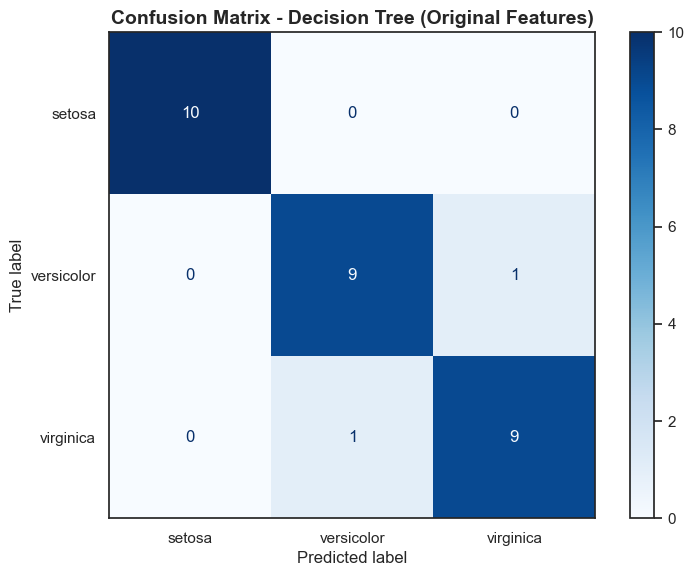

In [55]:
class_names=["setosa", "versicolor", "virginica"]

cm = confusion_matrix(y_test, y_preds_original, labels=clf_original.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Decision Tree (Original Features)", fontweight="bold", fontsize=14)
plt.show()

* 📌 The confusion matrix reveals that the decision tree model predicts **setosa** with perfect accuracy—all setosa samples are correctly classified.
* 📌 The primary classification errors occur between virginica and versicolor:
    * About 1 in 10 virginica samples are misclassified as versicolor, and about 1 in 10 versicolor samples are misclassified as virginica.
    * From a prediction perspective:
        * Among flowers labeled as versicolor by the model, roughly 9 out of 10 are truly versicolor.
        * Among those labeled as virginica, roughly 9 out of 10 are truly virginica.
* 📌 These misclassifications indicate that the model has slight difficulty distinguishing between versicolor and virginica, which is consistent with their overlapping feature distributions observed in earlier EDA.

### 8.2. Tree Visualization and Interpretation
Before assessing business impact, let's visualize the structure of our decision tree model. This reveals exactly how the model uses floral measurements to split the classes, making its decision-making transparent to stakeholders.

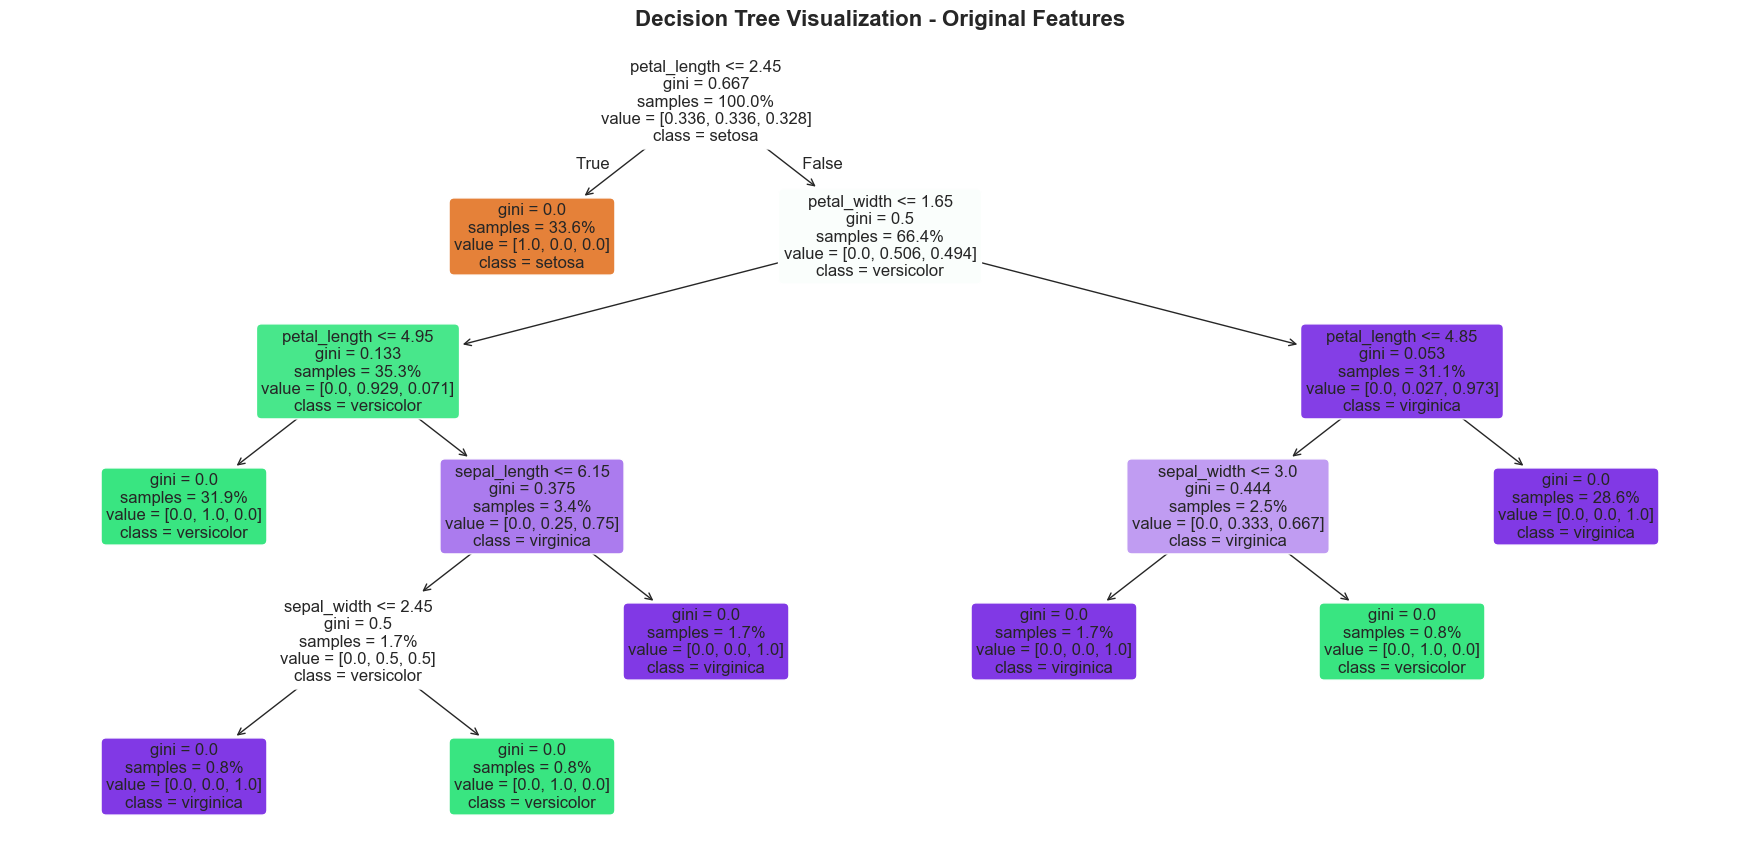

In [59]:
plt.figure(figsize=(20, 10))
plot_tree(
    clf_original,
    feature_names=X_train_original.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=12,
    impurity=True,
    proportion=True
)
plt.title("Decision Tree Visualization - Original Features", fontsize=16, fontweight="bold")
plt.show()

* 📌 **Model Transparency:** The decision tree structure clearly shows how the model makes its predictions, with each split corresponding to a simple rule about a single flower measurement.
* 📌 **Key Decision Feature:** The very first split (root node) is based on **petal length** (e.g., "petal_length ≤ 2.45 cm"), instantly dividing setosa from the other species. This confirms earlier EDA that petal measurements are highly predictive.
* 📌 **Setosa Separation:** All samples with petal length ≤ 2.45 cm are classified as **setosa**—a rule that is both simple and botanically meaningful.
* 📌 **Further Splits:** For non-setosa flowers, the tree next splits on **petal width** and sometimes **petal length** again to distinguish between **versicolor** and **virginica**.
* 📌 **Interpretability:** Each path in the tree gives an explicit, human-readable chain of rules leading to the final class, making the model decisions easy to explain to stakeholders.
* 📌 **Depth and Overfitting:** The tree achieves high test accuracy with a moderate depth, suggesting it finds key patterns without severe overfitting in this dataset.


### 8.3. Business Impact Report

- **Automation of Species Identification**: The decision tree model enables rapid, automated identification of iris species using only four simple anatomical measurements. This addresses the institute’s business goal of reducing slow and costly manual inspections.
- **Model Transparency Boosts Trust**: As a white-box model, the decision tree provides complete transparency: each classification decision is based on a clear, human-readable set of rules. This transparency builds stakeholder confidence, supports regulatory compliance, and facilitates adoption in production and research workflows.
- **Rule-Based Knowledge Transfer**: The learned tree structure surfaces simple, botanical rules (e.g., “petal_length ≤ 2.45 cm → setosa”) that can supplement or replace many traditional manual identification procedures, making botanical expertise more accessible.
- **Operational Efficiency**: With an accuracy of 93%, the model drastically reduces the error-prone, subjective elements of species classification. This improves efficiency, consistency, and scalability in plant identification tasks.
- **Insightful Feature Importance**: The model confirms—via both splits and feature importance—the business insight that petal measurements are the most distinctive characteristics among Iris species. This can re-focus future measurement and research efforts for even greater process efficiency.
- **Foundation for Further Innovation**: The interpretable baseline provided by the decision tree can be used as a reference for more complex models (e.g., ensembles) or integrated into digital field guides and automated lab processes.

---

> ### 📝 8.4. Model Evaluation Report (Summary)
> 
> - **Performance:** The decision tree classifier achieved high overall performance, with 93.3% accuracy and balanced precision, recall, and F1-score on the held-out test set when using the original features. Most notably, the model perfectly classified all setosa samples, with errors concentrated in distinguishing between versicolor and virginica.
> - **Insights Gained:** Visualization of the confusion matrix and the decision tree structure provided clear evidence of balanced classification across classes and high model interpretability, confirming that petal measurements are the most decisive features for species identification.
> - **Strengths:** The model is fully transparent (“white-box”), allowing its decision logic to be understood and audited by non-technical stakeholders. Its human-readable rules offer operational value and increase trust.
> - **Limitations:** Misclassifications between versicolor and virginica remain, and engineered features did not improve performance beyond using the original four measurements. The study also has not yet explored the possible benefits of more advanced models or ensembles.
> - **Deployment Decision:** **No-Go for Deployment (Yet):**  
>     - Although the decision tree demonstrates strong and interpretable performance, it should not be deployed as the final solution at this stage. The evaluation and selection process is ongoing, with additional candidate models and ensemble methods still to be implemented and compared in future stages of the project.
> 
---

**Next:** [Regression Trees Theory](./11_regression_trees_theory.md)